<a href="https://colab.research.google.com/github/CarlosFranciscoM-Urzua/EJERCICIOS_PLN_COLAB/blob/main/EJERCICIO_INTEGRADOR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import re

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Analisis del texto siguiente:

In [2]:
texto = '''
La inteligencia artificial está transformando la industria moderna.
Las empresas utilizan inteligencia artificial para automatizar procesos,
analizar datos y mejorar la toma de decisiones.
'''

1. Generar los unigramas.


In [4]:
texto = texto.lower()
texto_limpio = re.sub(r'^[a-záéíóúüñ]\s', '', texto)
texto_limpio = re.sub(r'[,.]', '', texto)

tokens = word_tokenize(texto_limpio)
tokens

['la',
 'inteligencia',
 'artificial',
 'está',
 'transformando',
 'la',
 'industria',
 'moderna',
 'las',
 'empresas',
 'utilizan',
 'inteligencia',
 'artificial',
 'para',
 'automatizar',
 'procesos',
 'analizar',
 'datos',
 'y',
 'mejorar',
 'la',
 'toma',
 'de',
 'decisiones']

2. Eliminar stopwords.


In [5]:
stop_words = set(stopwords.words('spanish'))
signos = set([',','.', ' '])

tokens_filtrado = [
    palabra
    for palabra in tokens
    if palabra not in stop_words and palabra not in signos
]

tokens_filtrado

['inteligencia',
 'artificial',
 'transformando',
 'industria',
 'moderna',
 'empresas',
 'utilizan',
 'inteligencia',
 'artificial',
 'automatizar',
 'procesos',
 'analizar',
 'datos',
 'mejorar',
 'toma',
 'decisiones']

3. Crear la tabla de frecuencias.


In [6]:
frecuencias = Counter(tokens_filtrado)

df = pd.DataFrame(
    frecuencias.items(),
    columns=['Palabra', 'Frecuencia']
)

df = df.sort_values(
    by='Frecuencia',
    ascending=False
)

df

,Palabra,Frecuencia
0,inteligencia,2
1,artificial,2
2,transformando,1
3,industria,1
4,moderna,1
5,empresas,1
6,utilizan,1
7,automatizar,1
8,procesos,1
9,analizar,1


4. Graficar los resultados.


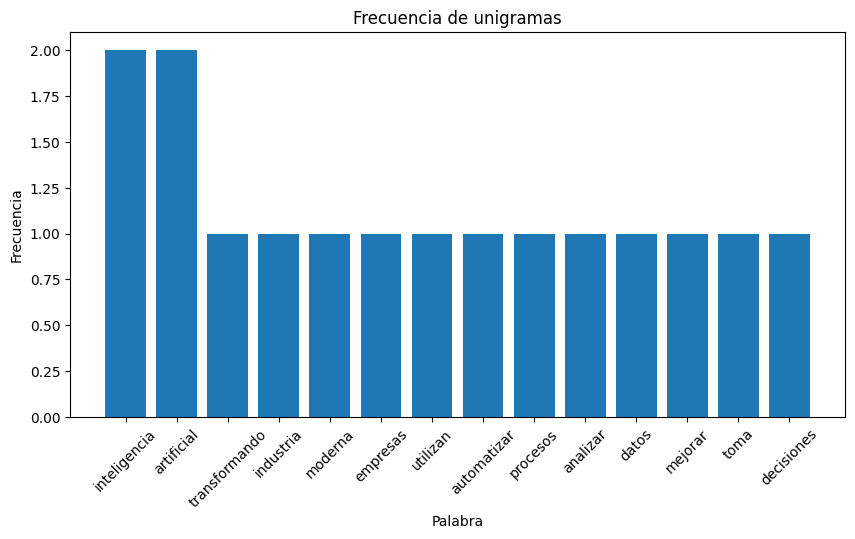

In [7]:
plt.figure(figsize=(10,5))

plt.bar(
    df['Palabra'],
    df['Frecuencia']
)

plt.xticks(rotation=45)
plt.title('Frecuencia de unigramas')
plt.xlabel('Palabra')
plt.ylabel('Frecuencia')

plt.show()

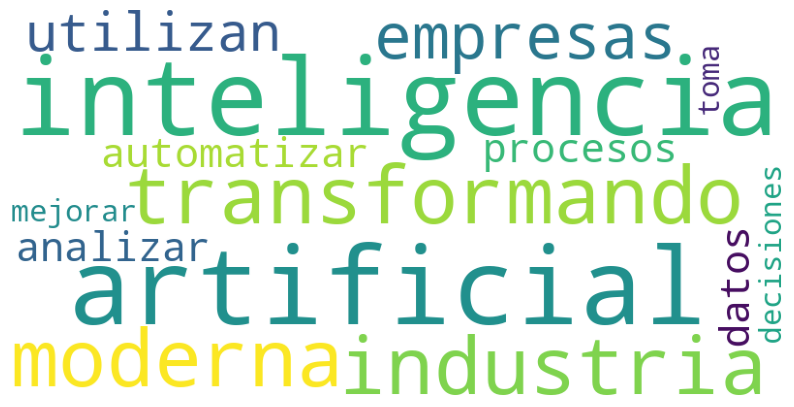

In [10]:
texto_wc = " ".join(tokens_filtrado)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(texto_wc)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

5. Identificar los 3 términos más importantes del texto.

In [11]:
df.head(3)

,Palabra,Frecuencia
0,inteligencia,2
1,artificial,2
2,transformando,1
